# Pruebas de Bondad de Ajuste

## Definición
Las pruebas de bondad de ajuste son procedimientos estadísticos que permiten determinar si una muestra de datos proviene de una población con una distribución teórica específica (normal, exponencial, Poisson, etc.).

## Tipos de pruebas

### 1. Métodos gráficos
- Histograma vs curva teórica
- Gráfico Q-Q (Quantile-Quantile)
- Gráfico P-P (Probability-Probability)
- Diagrama de caja

### 2. Métodos analíticos (pruebas estadísticas)
- Prueba de Kolmogorov-Smirnov (K-S)
- Prueba de Shapiro-Wilk (normalidad)
- Prueba de Anderson-Darling
- Prueba de Chi-cuadrado de Pearson
- Prueba de Jarque-Bera

## Importación de librerías necesarias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# Configuración de gráficos
sns.set_style("whitegrid")
#np.random.seed(42)
np.random.default_rng()

Generator(PCG64) at 0x7A3E86EC6340

## Pruebas gráficas para evaluar distribuciones

Las pruebas gráficas son métodos visuales para analizar si una muestra sigue una distribución teórica (por ejemplo, normal). No dan una decisión formal como un p-value, pero son muy útiles para diagnóstico.

---

# 1. Histograma vs curva teórica

## ¿Qué es?

Consiste en comparar la forma del histograma de los datos con la **curva de densidad teórica** (por ejemplo, normal).

---

##  Idea

- El histograma representa la distribución empírica
- La curva teórica representa la distribución esperada

---

##  Interpretación

- Buen ajuste → las barras siguen la forma de la curva
- Mal ajuste → diferencias en forma, sesgo o dispersión

---

##  Uso típico

$$
\text{Comparar } f_{empírica}(x) \text{ vs } f_{teórica}(x)
$$

---

# 2. Gráfico Q–Q (Quantile–Quantile)

## ¿Qué es?

Compara los **cuantiles de los datos** con los **cuantiles de una distribución teórica**.

---

##  Idea matemática

Se comparan:

- Cuantiles empíricos: $x_{(i)}$
- Cuantiles teóricos: $q_i$

---

##  Interpretación

- Si los puntos están sobre una línea recta → buena concordancia
- Curvatura → desviaciones de normalidad
  - Forma en “S” → colas diferentes
  - Desviación en extremos → outliers o colas pesadas

---

##  Relación ideal

$$
x_{(i)} \approx q_i
$$

---

# 3. Gráfico P–P (Probability–Probability)

## ¿Qué es?

Compara las **probabilidades acumuladas empíricas** con las **probabilidades teóricas**.

---

##  Idea

Se grafican:

- $F_n(x)$: distribución empírica
- $F(x)$: distribución teórica

---

##  Interpretación

- Puntos cerca de la diagonal → buen ajuste
- Desviaciones sistemáticas → mala especificación de la distribución

---

##  Diferencia con Q–Q

- Q–Q: compara cuantiles (más sensible en colas)
- P–P: compara probabilidades (más sensible en el centro)

---

# 4. Diagrama de caja (Boxplot)

## ¿Qué es?

Es una representación gráfica basada en **cuartiles** que muestra la dispersión y simetría de los datos.

---

##  Componentes

- $Q_1$: primer cuartil (25%)
- $Q_2$: mediana (50%)
- $Q_3$: tercer cuartil (75%)
- Rango intercuartílico:
$$
IQR = Q_3 - Q_1
$$

---

##  Bigotes

Los bigotes suelen extenderse hasta:

$$
[Q_1 - 1.5 \cdot IQR,\; Q_3 + 1.5 \cdot IQR]
$$

---

##  Interpretación

- Caja simétrica → distribución aproximadamente simétrica
- Mediana desplazada → sesgo
- Muchos puntos fuera → outliers

---

#  Resumen general

| Método | Qué compara | Uso principal |
|--------|------------|--------------|
| Histograma vs curva | Densidad | Forma general |
| Q–Q plot | Cuantiles | Normalidad y colas |
| P–P plot | Probabilidades acumuladas | Ajuste global |
| Boxplot | Cuartiles | Simetría y outliers |

---

##  Conclusión

Estas pruebas gráficas no reemplazan pruebas formales (como Shapiro–Wilk o K–S), pero son esenciales para:

- Detectar desviaciones visuales
- Identificar outliers
- Evaluar rápidamente normalidad o ajuste de distribución

---

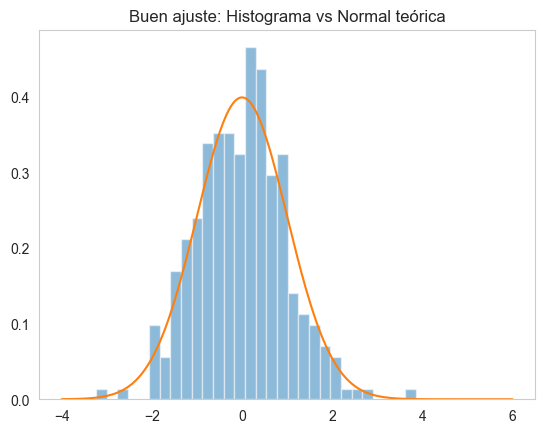

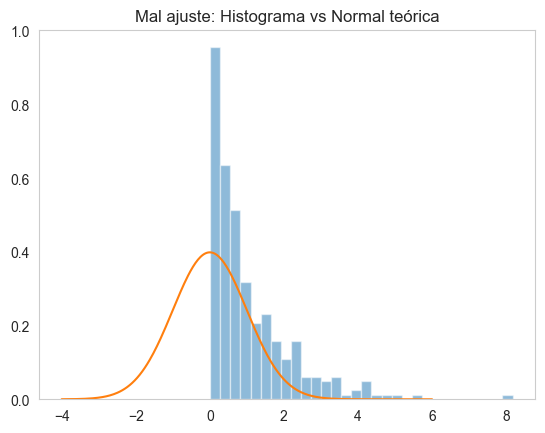

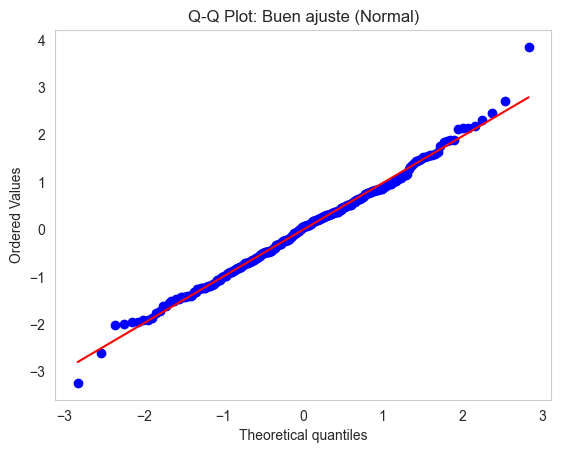

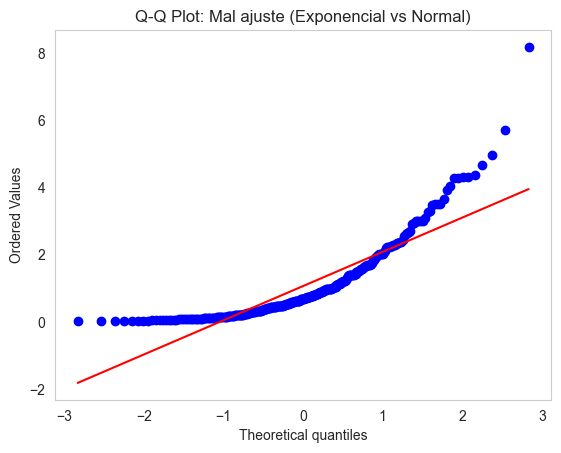

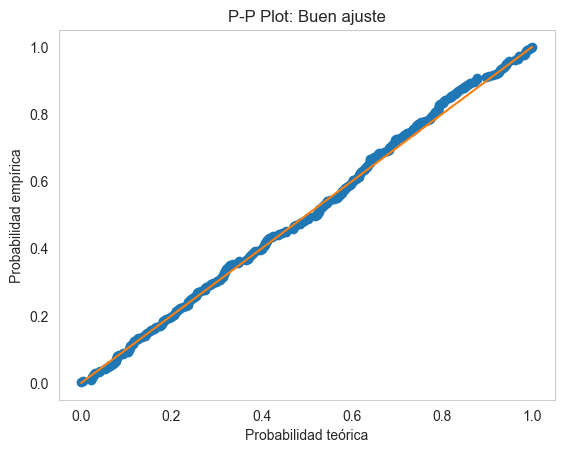

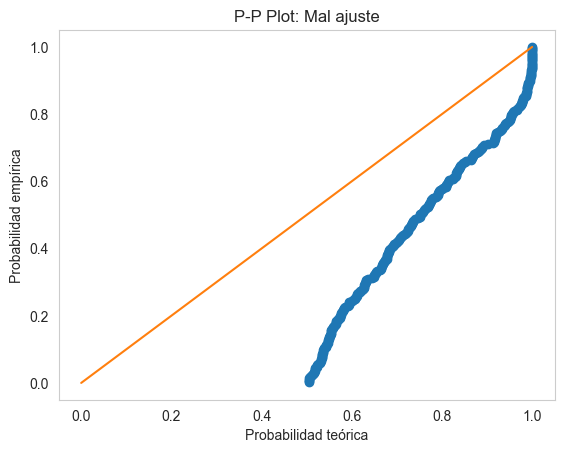

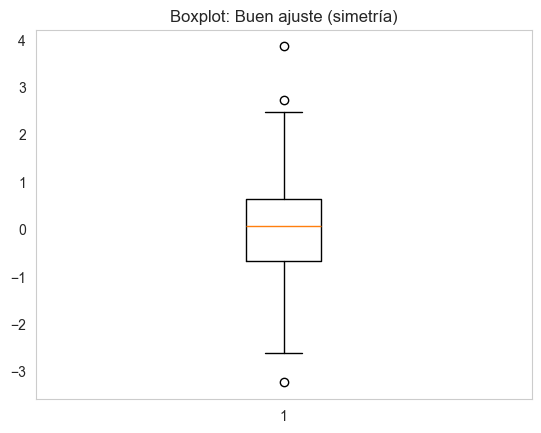

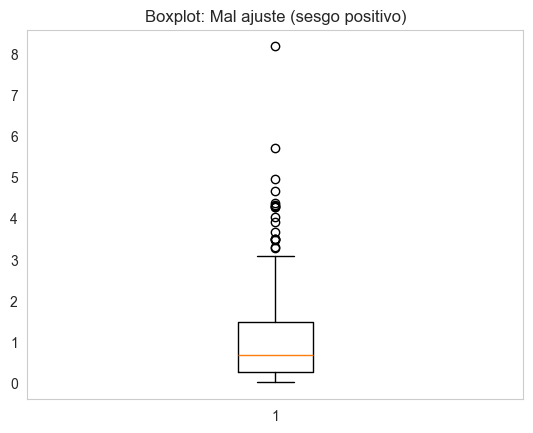

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =========================
# 1. Datos
# =========================
np.random.seed(42)

# Buen ajuste: normal
data_good = np.random.normal(0, 1, 300)

# Mal ajuste: exponencial (sesgada)
data_bad = np.random.exponential(1, 300)

x = np.linspace(-4, 6, 300)

# ==========================================================
# 2. HISTOGRAMA vs CURVA TEÓRICA
# ==========================================================

# --- Buen ajuste ---
plt.figure()
plt.hist(data_good, bins=30, density=True, alpha=0.5)
plt.plot(x, stats.norm.pdf(x, 0, 1))
plt.title("Buen ajuste: Histograma vs Normal teórica")
plt.grid()
plt.show()

# --- Mal ajuste ---
plt.figure()
plt.hist(data_bad, bins=30, density=True, alpha=0.5)
plt.plot(x, stats.norm.pdf(x, 0, 1))
plt.title("Mal ajuste: Histograma vs Normal teórica")
plt.grid()
plt.show()

# ==========================================================
# 3. Q-Q PLOT
# ==========================================================

# --- Buen ajuste ---
plt.figure()
stats.probplot(data_good, dist="norm", plot=plt)
plt.title("Q-Q Plot: Buen ajuste (Normal)")
plt.grid()
plt.show()

# --- Mal ajuste ---
plt.figure()
stats.probplot(data_bad, dist="norm", plot=plt)
plt.title("Q-Q Plot: Mal ajuste (Exponencial vs Normal)")
plt.grid()
plt.show()

# ==========================================================
# 4. P-P PLOT
# ==========================================================

def pp_plot(data, dist="norm", title=""):
    data_sorted = np.sort(data)
    n = len(data)

    emp_probs = np.arange(1, n + 1) / n

    if dist == "norm":
        theo_probs = stats.norm.cdf(data_sorted)

    plt.figure()
    plt.plot(theo_probs, emp_probs, marker="o", linestyle="none")
    plt.plot([0, 1], [0, 1])
    plt.title(title)
    plt.xlabel("Probabilidad teórica")
    plt.ylabel("Probabilidad empírica")
    plt.grid()
    plt.show()

# --- Buen ajuste ---
pp_plot(data_good, "norm", "P-P Plot: Buen ajuste")

# --- Mal ajuste ---
pp_plot(data_bad, "norm", "P-P Plot: Mal ajuste")

# ==========================================================
# 5. BOXPLOT
# ==========================================================

# --- Buen ajuste ---
plt.figure()
plt.boxplot(data_good)
plt.title("Boxplot: Buen ajuste (simetría)")
plt.grid()
plt.show()

# --- Mal ajuste ---
plt.figure()
plt.boxplot(data_bad)
plt.title("Boxplot: Mal ajuste (sesgo positivo)")
plt.grid()
plt.show()

## Prueba de Kolmogorov–Smirnov (K–S)

### ¿Qué es?

La prueba de Kolmogorov–Smirnov es una prueba no paramétrica que se utiliza para comparar distribuciones. Tiene dos usos principales:

1. **Prueba de una muestra (1-sample K–S):**  
   Determina si una muestra proviene de una distribución teórica específica.

2. **Prueba de dos muestras (2-sample K–S):**  
   Compara dos muestras independientes para verificar si provienen de la misma distribución.

---

### Idea principal

La prueba compara funciones de distribución acumulada (FDA):

- \( F_n(x) \): función de distribución empírica  
- \( F(x) \): función de distribución teórica  
- \( G_m(x) \): FDA de una segunda muestra  

La estadística mide la máxima diferencia entre ellas.

---

### Estadístico de prueba

#### Caso 1: Una muestra

$$
D_n = \sup_{x} \left| F_n(x) - F(x) \right|
$$

#### Caso 2: Dos muestras

$$
D_{n,m} = \sup_{x} \left| F_n(x) - G_m(x) \right|
$$

---

### ¿Cómo se calcula? (una muestra)

1. Ordenar los datos:
$$
x_{(1)}, x_{(2)}, \dots, x_{(n)}
$$

2. Función de distribución empírica:
$$
F_n(x_{(i)}) = \frac{i}{n}
$$

3. Evaluar la distribución teórica:
$$
F(x_{(i)})
$$

4. Calcular diferencias:
$$
D_i^+ = \frac{i}{n} - F(x_{(i)})
$$

$$
D_i^- = F(x_{(i)}) - \frac{i-1}{n}
$$

5. Estadístico final:
$$
D_n = \max \left( \max_i D_i^+, \max_i D_i^- \right)
$$

---

### Regla de decisión

- Hipótesis nula:
$$
H_0: \text{La muestra sigue la distribución } F(x)
$$

- Hipótesis alternativa:
$$
H_1: \text{La muestra no sigue la distribución } F(x)
$$

Decisión:

- Si $ p\text{-value} < \alpha $ → rechazar $ H_0 $
- Si $ p\text{-value} \geq \alpha $ → no rechazar $ H_0 $

---

### Interpretación

- Si \( D_n \) es pequeño, buena concordancia  
- Si \( D_n \) es grande, diferencias significativas  

---


Estadístico D = 0.10357070563896065
p-value = 0.2180555337851624


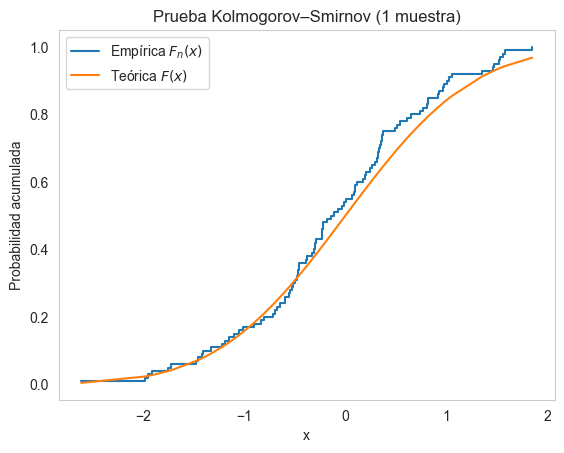

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =========================
# 1. Simular datos
# =========================
np.random.seed(42)

# Generamos 100 datos de una normal N(0,1)
data = np.random.normal(loc=0, scale=1, size=100)

# =========================
# 2. Prueba Kolmogorov-Smirnov
# =========================
D, p_value = stats.kstest(data, 'norm')

print("Estadístico D =", D)
print("p-value =", p_value)

# =========================
# 3. Construcción de funciones
# =========================

# Ordenar los datos
x_sorted = np.sort(data)

# Tamaño de muestra
n = len(data)

# Función empírica
Fn = np.arange(1, n + 1) / n

# Función teórica (Normal estándar)
F = stats.norm.cdf(x_sorted, loc=0, scale=1)

# =========================
# 4. Graficar
# =========================
plt.figure()

# FDA empírica (escalonada)
plt.step(x_sorted, Fn, where='post', label='Empírica $F_n(x)$')

# FDA teórica (suave)
plt.plot(x_sorted, F, label='Teórica $F(x)$')

plt.xlabel('x')
plt.ylabel('Probabilidad acumulada')
plt.title('Prueba Kolmogorov–Smirnov (1 muestra)')
plt.legend()
plt.grid()

plt.show()

p-value:

Si $p<0.05$:  se rechaza $H_0$

Si $p\geq 0.05: \text{ no se rechaza } $H_0$	​


## Prueba de Shapiro–Wilk

### ¿Qué es?

La prueba de Shapiro–Wilk es una prueba estadística que se utiliza para evaluar si una muestra proviene de una **distribución normal**.

Es una de las pruebas más utilizadas para verificar **normalidad**, especialmente en muestras pequeñas y medianas.

---

### Hipótesis

- Hipótesis nula:
$$
H_0: \text{Los datos provienen de una distribución normal}
$$

- Hipótesis alternativa:
$$
H_1: \text{Los datos no provienen de una distribución normal}
$$

---

### Idea principal

La prueba compara:

- Los datos ordenados de la muestra
- Con los valores esperados si los datos fueran normales

Es decir, mide qué tan bien los datos siguen el patrón esperado de una normal.

---

### Estadístico de prueba

El estadístico de Shapiro–Wilk es:

$$
W = \frac{\left( \sum_{i=1}^{n} a_i \, x_{(i)} \right)^2}{\sum_{i=1}^{n} (x_i - \bar{x})^2}
$$

donde:

- $x_{(i)}$: datos ordenados  
- $\bar{x}$: media muestral  
- $a_i$: constantes calculadas a partir de los valores esperados de una normal  
- $n$: tamaño de la muestra  

---

### Interpretación del estadístico

- $W \approx 1$: los datos son consistentes con normalidad  
- $W$ pequeño: evidencia contra la normalidad  

---

### ¿Cómo se calcula? (idea general)

1. Ordenar los datos:
$$
x_{(1)}, x_{(2)}, \dots, x_{(n)}
$$

2. Calcular la media:
$$
\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

3. Usar coeficientes $a_i$ (precalculados)

4. Evaluar el estadístico $W$

---

### Regla de decisión

- Si $p\text{-value} < \alpha$ → rechazar $H_0$
- Si $p\text{-value} \geq \alpha$ → no rechazar $H_0$

---


=== Datos normales ===
W = 0.9898833815158516 p-value = 0.6551676754214818

=== Datos no normales ===
W = 0.8405631661173513 p-value = 5.396184451200884e-09


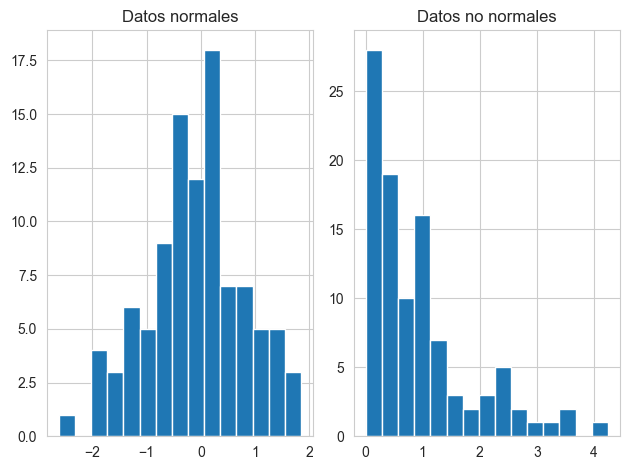

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =========================
# 1. Simulación de datos
# =========================
np.random.seed(42)

# Caso 1: datos normales
data_normal = np.random.normal(loc=0, scale=1, size=100)

# Caso 2: datos no normales (exponencial)
data_no_normal = np.random.exponential(scale=1, size=100)

# =========================
# 2. Prueba de Shapiro-Wilk
# =========================
W1, p1 = stats.shapiro(data_normal)
W2, p2 = stats.shapiro(data_no_normal)

print("=== Datos normales ===")
print("W =", W1, "p-value =", p1)

print("\n=== Datos no normales ===")
print("W =", W2, "p-value =", p2)

# =========================
# 3. Gráficas
# =========================
plt.figure()

plt.subplot(1, 2, 1)
plt.hist(data_normal, bins=15)
plt.title("Datos normales")

plt.subplot(1, 2, 2)
plt.hist(data_no_normal, bins=15)
plt.title("Datos no normales")

plt.tight_layout()
plt.show()

## Prueba de Anderson–Darling

### ¿Qué es?

La prueba de Anderson–Darling es una prueba estadística utilizada para verificar si una muestra proviene de una distribución específica, siendo la más común la **distribución normal**.

Es una mejora de la prueba de Kolmogorov–Smirnov, ya que da **más peso a las colas de la distribución**, lo que la hace más sensible a desviaciones en los extremos.

---

### Hipótesis

- Hipótesis nula:
$$
H_0: \text{La muestra proviene de la distribución especificada (por ejemplo, normal)}
$$

- Hipótesis alternativa:
$$
H_1: \text{La muestra no proviene de esa distribución}
$$

---

### Idea principal

La prueba compara la **función de distribución empírica** con la **función de distribución teórica**, pero ponderando más las diferencias en las colas.

---

### Estadístico de prueba

El estadístico de Anderson–Darling es:

$$
A^2 = -n - \frac{1}{n} \sum_{i=1}^{n} (2i - 1)\left[ \ln(F(x_{(i)})) + \ln(1 - F(x_{(n+1-i)})) \right]
$$

donde:

- $n$: tamaño de la muestra  
- $x_{(i)}$: datos ordenados  
- $F(x)$: función de distribución acumulada teórica  

---

### Interpretación del estadístico

- Valores pequeños de $A^2$ → buena concordancia con la distribución  
- Valores grandes de $A^2$ → evidencia contra la distribución asumida  

---

### Regla de decisión

A diferencia de otras pruebas, Anderson–Darling usa **valores críticos tabulados**:

- Si $A^2$ es mayor que el valor crítico → rechazar $H_0$
- Si $A^2$ es menor o igual → no rechazar $H_0$

También puede utilizarse el **p-value** (en implementaciones modernas).

---

### ¿Qué la hace especial?

- Más sensible que Kolmogorov–Smirnov  
- Da más importancia a las colas de la distribución  
- Muy usada para pruebas de normalidad  

---

### Ventajas

- Alta potencia estadística  
- Detecta bien desviaciones en colas  
- Adecuada para normalidad y otras distribuciones  

---

### Limitaciones

- Depende de valores críticos específicos según la distribución  
- Más compleja que K–S  
- Sensible a tamaño de muestra  

---

### Resumen

La prueba de Anderson–Darling evalúa qué tan bien una muestra se ajusta a una distribución teórica, con énfasis especial en las colas, lo que la hace más precisa que otras pruebas como Kolmogorov–Smirnov en muchos casos.

=== Datos normales ===
Estadístico A² = 0.25343395875111696
Valores críticos: [0.555 0.632 0.759 0.885 1.053]
Niveles de significancia: [15.  10.   5.   2.5  1. ]

=== Datos no normales ===
Estadístico A² = 4.920815370897088
Valores críticos: [0.555 0.632 0.759 0.885 1.053]
Niveles de significancia: [15.  10.   5.   2.5  1. ]


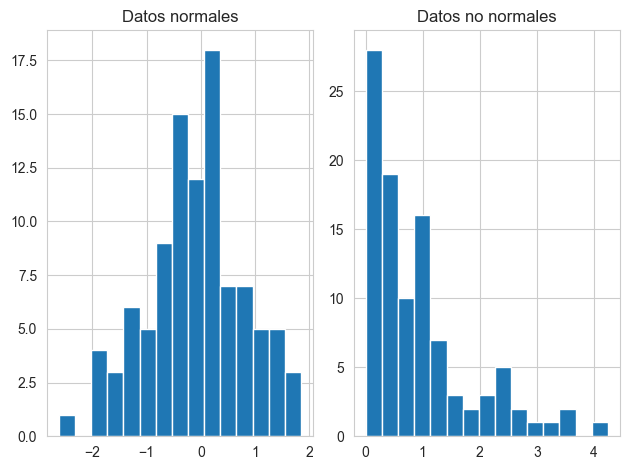

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =========================
# 1. Simulación de datos
# =========================
np.random.seed(42)

# Datos normales
data_normal = np.random.normal(loc=0, scale=1, size=100)

# Datos no normales (exponencial)
data_no_normal = np.random.exponential(scale=1, size=100)

# =========================
# 2. Prueba Anderson-Darling
# =========================
result_normal = stats.anderson(data_normal, dist='norm')
result_no_normal = stats.anderson(data_no_normal, dist='norm')

print("=== Datos normales ===")
print("Estadístico A² =", result_normal.statistic)
print("Valores críticos:", result_normal.critical_values)
print("Niveles de significancia:", result_normal.significance_level)

print("\n=== Datos no normales ===")
print("Estadístico A² =", result_no_normal.statistic)
print("Valores críticos:", result_no_normal.critical_values)
print("Niveles de significancia:", result_no_normal.significance_level)

# =========================
# 3. Gráficas
# =========================
plt.figure()

plt.subplot(1, 2, 1)
plt.hist(data_normal, bins=15)
plt.title("Datos normales")

plt.subplot(1, 2, 2)
plt.hist(data_no_normal, bins=15)
plt.title("Datos no normales")

plt.tight_layout()
plt.show()

## Prueba de Chi-cuadrado de Pearson

### ¿Qué es?

La prueba de **Chi-cuadrado de Pearson** es una prueba estadística utilizada para analizar **datos categóricos**. Sirve principalmente para evaluar si existe una diferencia significativa entre **frecuencias observadas** y **frecuencias esperadas**.

Se usa en dos contextos principales:

1. **Prueba de bondad de ajuste**: verificar si una distribución observada sigue una distribución teórica.
2. **Prueba de independencia**: verificar si dos variables categóricas son independientes.

---

##  Idea principal

La prueba mide qué tanto difieren las frecuencias observadas de las esperadas bajo la hipótesis nula.

---

##  Estadístico de prueba

El estadístico de Chi-cuadrado de Pearson es:

$$
\chi^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}
$$

donde:

- $O_i$: frecuencia observada en la categoría $i$
- $E_i$: frecuencia esperada en la categoría $i$
- $k$: número de categorías

---

##  Hipótesis

### Bondad de ajuste:
- $H_0$: los datos siguen la distribución esperada  
- $H_1$: los datos no siguen la distribución esperada  

### Independencia:
- $H_0$: las variables son independientes  
- $H_1$: las variables no son independientes  

---

##  Cálculo de frecuencias esperadas

### Caso de bondad de ajuste:
$$
E_i = n \cdot p_i
$$

donde:
- $n$: tamaño de la muestra
- $p_i$: probabilidad teórica de la categoría $i$

---

### Caso de independencia (tabla de contingencia):

$$
E_{ij} = \frac{(\text{total fila}_i)(\text{total columna}_j)}{n}
$$

---

##  Regla de decisión

Se compara el estadístico con una distribución Chi-cuadrado:

- Si $p\text{-value} < \alpha$ → se rechaza $H_0$
- Si $p\text{-value} \geq \alpha$ → no se rechaza $H_0$

También puede usarse valor crítico:

$$
\chi^2 > \chi^2_{\alpha, \, gl}
$$

---

##  Grados de libertad

- Bondad de ajuste:
$$
gl = k - 1
$$

- Independencia:
$$
gl = (r - 1)(c - 1)
$$

donde:
- $r$: número de filas
- $c$: número de columnas

---

##  Interpretación

- Valor pequeño de $\chi^2$: buena concordancia entre observado y esperado  
- Valor grande de $\chi^2$: diferencias significativas  

---

##  Supuestos importantes

- Observaciones independientes  
- Frecuencias esperadas suficientemente grandes (generalmente $E_i \geq 5$)  
- Datos categóricos  

---

##  Ventajas

- Fácil de aplicar  
- No requiere distribución normal  
- Muy usada en datos categóricos  

---

##  Limitaciones

- No funciona bien con frecuencias pequeñas  
- Sensible al tamaño de muestra (muestras grandes detectan diferencias muy pequeñas)  
- No indica dirección de la diferencia, solo existencia  

---

##  Resumen

La prueba Chi-cuadrado de Pearson evalúa si las diferencias entre frecuencias observadas y esperadas son suficientemente grandes como para concluir que no provienen del mismo modelo teórico o que las variables no son independientes.

## Ejemplo: Prueba de independencia

¿El género y la preferencia de producto son independientes?

Interpretación
- $H_0$: Las variables son independientes
- $H_1$: Las variables no son independientes

In [2]:
import numpy as np
from scipy.stats import chi2_contingency

# Tabla de contingencia (filas: género, columnas: producto)
#            A   B   C
# Hombre    20  15  30
# Mujer     25  20  35

tabla = np.array([
    [20, 15, 30],
    [25, 20, 35]
])

chi2, p, dof, expected = chi2_contingency(tabla)

print("Estadístico chi2:", chi2)
print("Valor p:", p)
print("Grados de libertad:", dof)
print("Frecuencias esperadas:\n", expected)

Estadístico chi2: 0.10384380576688267
Valor p: 0.9494030095851854
Grados de libertad: 2
Frecuencias esperadas:
 [[20.17241379 15.68965517 29.13793103]
 [24.82758621 19.31034483 35.86206897]]


In [3]:
alpha = 0.05

if p < alpha:
    print("Rechazar H0: hay dependencia")
else:
    print("No se rechaza H0: son independientes")

No se rechaza H0: son independientes


## Prueba de bondad de ajuste

 Ejemplo: ¿Un dado es justo?
- $H_0$: Sigue la distribución esperada (dado justo)
- $H_1$: No sigue la distribución

In [4]:
from scipy.stats import chisquare

# Frecuencias observadas (resultados del dado)
observado = [10, 12, 8, 15, 9, 6]

# Frecuencias esperadas (dado justo)
esperado = [10, 10, 10, 10, 10, 10]

chi2, p = chisquare(f_obs=observado, f_exp=esperado)

print("Estadístico chi2:", chi2)
print("Valor p:", p)

Estadístico chi2: 5.0
Valor p: 0.4158801869955079


In [5]:
alpha = 0.05

if p < alpha:
    print("Rechazar H0: el dado no es justo")
else:
    print("No se rechaza H0: el dado podría ser justo")

No se rechaza H0: el dado podría ser justo


## Prueba de Jarque–Bera

### ¿Qué es?

La prueba de **Jarque–Bera (JB)** es una prueba estadística utilizada para evaluar si una muestra proviene de una **distribución normal**, basándose en dos características clave:

- **Asimetría (skewness)**  
- **Curtosis (kurtosis)**  

Es muy usada en econometría y análisis de datos para verificar normalidad.

---

##  Hipótesis

- Hipótesis nula:
$$
H_0: \text{Los datos siguen una distribución normal}
$$

- Hipótesis alternativa:
$$
H_1: \text{Los datos no siguen una distribución normal}
$$

---

##  Idea principal

Una distribución normal cumple:

- Asimetría = 0  
- Curtosis = 3  

La prueba mide qué tan lejos están los datos de estos valores.

---

##  Estadístico de prueba

El estadístico de Jarque–Bera es:

$$
JB = \frac{n}{6} \left( S^2 + \frac{(K - 3)^2}{4} \right)
$$

donde:

- $n$: tamaño de la muestra  
- $S$: asimetría muestral  
- $K$: curtosis muestral  

---

##  Interpretación

- Si los datos son normales:
  - $S \approx 0$
  - $K \approx 3$
  - Entonces $JB \approx 0$

- Si hay desviaciones:
  - Asimetría fuerte o curtosis anormal → $JB$ crece

---

##  Regla de decisión

El estadístico sigue aproximadamente una distribución:

$$
\chi^2 \text{ con 2 grados de libertad}
$$

Por lo tanto:

- Si $p\text{-value} < \alpha$ → rechazar $H_0$
- Si $p\text{-value} \geq \alpha$ → no rechazar $H_0$

---

##  Intuición

La prueba detecta dos tipos de desviaciones de normalidad:

- **Asimetría** (colas desbalanceadas)
- **Colas pesadas o ligeras** (curtosis diferente a 3)

---

##  Ventajas

- Simple de calcular  
- Solo usa dos estadísticos descriptivos  
- Muy usada en econometría  

---

##  Limitaciones

- Menos potente en muestras pequeñas  
- No detecta todas las formas de no normalidad  
- Sensible a outliers  

---

##  Comparación con otras pruebas

- Shapiro–Wilk → más potente en muestras pequeñas  
- Anderson–Darling → más sensible en colas  
- Jarque–Bera → más simple, basada en momentos (asimetría y curtosis)

---

##  Resumen

La prueba de Jarque–Bera evalúa normalidad midiendo si la asimetría es cercana a 0 y la curtosis cercana a 3, combinando ambas en un solo estadístico que sigue una distribución Chi-cuadrado.

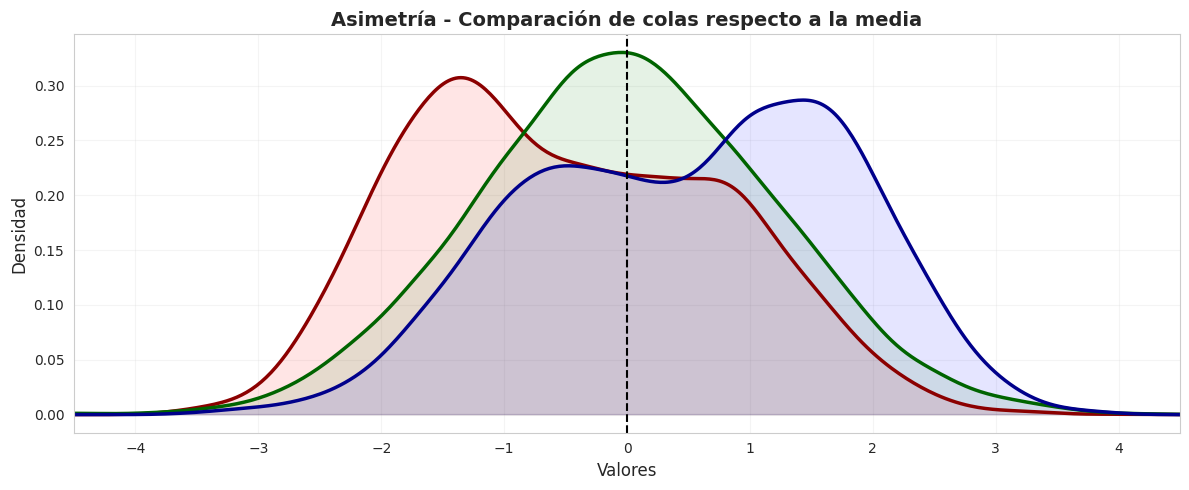

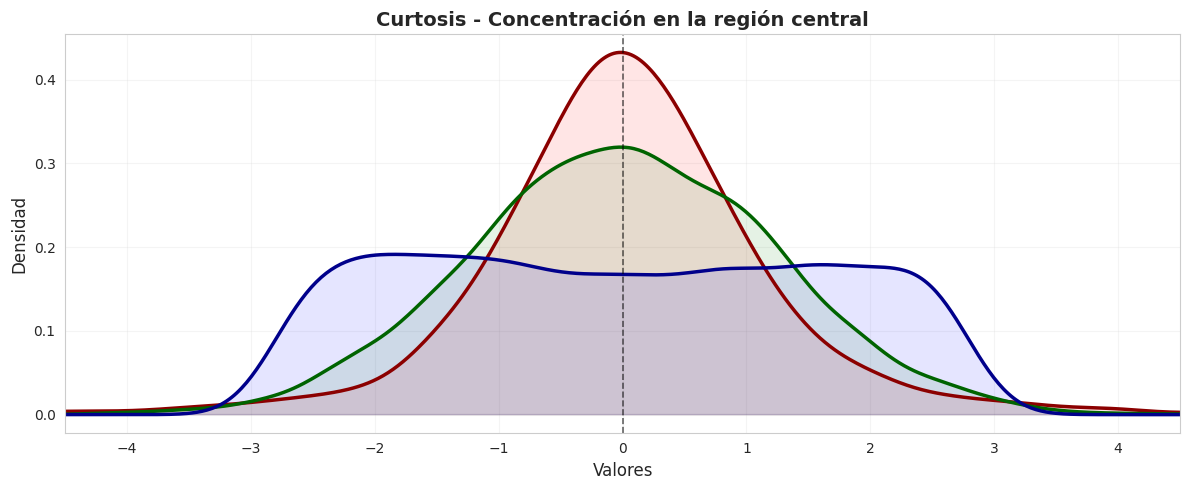

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Generar datos suaves para cada tipo de asimetría (misma media = 0)
np.random.seed(42)
n = 5000

# Media fija en 0 para todos
media = 0

# Asimetría Negativa (cola izquierda larga) - CA < 0
datos_neg = np.concatenate([
    np.random.normal(media - 1.5, 0.7, n//2),
    np.random.normal(media + 0.5, 0.9, n//2)
])

# Simétrica - CA = 0
datos_sim = np.random.normal(media, 1.2, n)

# Asimetría Positiva (cola derecha larga) - CA > 0
datos_pos = np.concatenate([
    np.random.normal(media - 0.5, 0.9, n//2),
    np.random.normal(media + 1.5, 0.7, n//2)
])

# Suavizado con kernel density estimation
x_vals = np.linspace(-5, 5, 500)
kde_neg = gaussian_kde(datos_neg)
kde_sim = gaussian_kde(datos_sim)
kde_pos = gaussian_kde(datos_pos)

y_neg = kde_neg(x_vals)
y_sim = kde_sim(x_vals)
y_pos = kde_pos(x_vals)

# Gráfica de ASIMETRÍA
plt.figure(figsize=(12, 5))

plt.plot(x_vals, y_neg, color='darkred', linewidth=2.5, label='Asimetría Negativa (CA < 0)')
plt.plot(x_vals, y_sim, color='darkgreen', linewidth=2.5, label='Simétrica (CA = 0)')
plt.plot(x_vals, y_pos, color='darkblue', linewidth=2.5, label='Asimetría Positiva (CA > 0)')

plt.axvline(x=media, color='black', linestyle='--', linewidth=1.5, label='Media (μ = 0)')
plt.fill_between(x_vals, y_neg, alpha=0.1, color='red')
plt.fill_between(x_vals, y_sim, alpha=0.1, color='green')
plt.fill_between(x_vals, y_pos, alpha=0.1, color='blue')

plt.title('Asimetría - Comparación de colas respecto a la media', fontsize=14, fontweight='bold')
plt.xlabel('Valores', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
#plt.legend(fontsize=10)
plt.grid(True, alpha=0.2)
plt.xlim(-4.5, 4.5)
plt.tight_layout()
plt.show()

# --- CURTOSIS (más suave y notorio) ---
from scipy.stats import beta

# Más curtosis (Leptocúrtica) - pico alto, colas gruesas
# Usamos t de Student con pocos grados de libertad
from scipy.stats import t
datos_mas_curtosis = t.rvs(df=3, loc=0, scale=0.8, size=n)

# Curtosis normal (Mesocúrtica)
datos_normal_curtosis = np.random.normal(0, 1.2, n)

# Menos curtosis (Platicúrtica) - distribución uniforme suavizada + normal ancha
datos_menos_curtosis = np.random.uniform(-2.8, 2.8, n)

x_vals2 = np.linspace(-5, 5, 500)
kde_mas = gaussian_kde(datos_mas_curtosis)
kde_normal = gaussian_kde(datos_normal_curtosis)
kde_menos = gaussian_kde(datos_menos_curtosis)

y_mas = kde_mas(x_vals2)
y_normal = kde_normal(x_vals2)
y_menos = kde_menos(x_vals2)

plt.figure(figsize=(12, 5))

plt.plot(x_vals2, y_mas, color='darkred', linewidth=2.5, label='Más Curtosis - Leptocúrtica (CU > 0)')
plt.plot(x_vals2, y_normal, color='darkgreen', linewidth=2.5, label='Curtosis Normal - Mesocúrtica (CU = 0)')
plt.plot(x_vals2, y_menos, color='darkblue', linewidth=2.5, label='Menos Curtosis - Platicúrtica (CU < 0)')

plt.axvline(x=0, color='black', linestyle='--', linewidth=1.2, alpha=0.6)

# Rellenos para destacar colas
plt.fill_between(x_vals2, y_mas, alpha=0.1, color='red')
plt.fill_between(x_vals2, y_normal, alpha=0.1, color='green')
plt.fill_between(x_vals2, y_menos, alpha=0.1, color='blue')

plt.title('Curtosis - Concentración en la región central', fontsize=14, fontweight='bold')
plt.xlabel('Valores', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
#plt.legend(fontsize=10)
plt.grid(True, alpha=0.2)
plt.xlim(-4.5, 4.5)
plt.tight_layout()
plt.show()



## Ejemplo en bondad de ajuste

=== Datos normales ===
JB = 4.058098596563737
p-value = 0.13146044142565277

=== Datos no normales ===
JB = 590.1964688936667
p-value = 6.925723681787361e-129


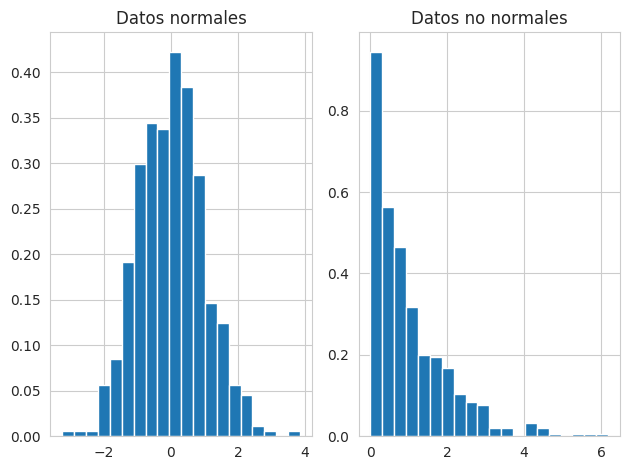

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =========================
# 1. Simulación de datos
# =========================
np.random.seed(42)

# Caso 1: datos normales
data_normal = np.random.normal(loc=0, scale=1, size=500)

# Caso 2: datos no normales (exponencial)
data_no_normal = np.random.exponential(scale=1, size=500)

# =========================
# 2. Prueba Jarque-Bera
# =========================
jb_normal = stats.jarque_bera(data_normal)
jb_no_normal = stats.jarque_bera(data_no_normal)

print("=== Datos normales ===")
print("JB =", jb_normal.statistic)
print("p-value =", jb_normal.pvalue)

print("\n=== Datos no normales ===")
print("JB =", jb_no_normal.statistic)
print("p-value =", jb_no_normal.pvalue)

# =========================
# 3. Gráficos: histogramas
# =========================
plt.figure()

plt.subplot(1, 2, 1)
plt.hist(data_normal, bins=20, density=True)
plt.title("Datos normales")

plt.subplot(1, 2, 2)
plt.hist(data_no_normal, bins=20, density=True)
plt.title("Datos no normales")

plt.tight_layout()
plt.show()
plt.show()

## Resumen de pruebas utilizadas

| Prueba | Tipo de datos | Hipótesis nula (H0) | Uso común |
|--------|--------------|----------------------|-----------|
| Shapiro-Wilk | Continuos | Los datos son normales | Muestras pequeñas (n<2000) |
| Kolmogorov-Smirnov | Continuos | Los datos siguen una distribución específica | Comparar con distribución teórica o dos muestras |
| Chi-cuadrado | Discretos o categóricos | Las frecuencias observadas igualan las esperadas | Datos en categorías |
| Anderson-Darling | Continuos | Los datos siguen una distribución específica | Más sensible en colas |
| Jarque-Bera | Continuos | Los datos tienen asimetría y curtosis como normal | Muestras grandes |

=== Shapiro-Wilk ===
0.9760902723490532 0.010181161454691156

=== Kolmogorov-Smirnov ===
0.08945440179507252 0.17058360931631134

=== Jarque-Bera ===
4.4858754373509475 0.1061462181718774

=== Anderson-Darling ===
0.8891994860134105
[0.562 0.64  0.767 0.895 1.065]


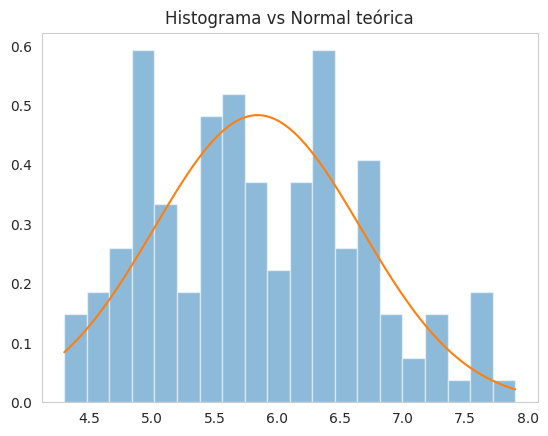

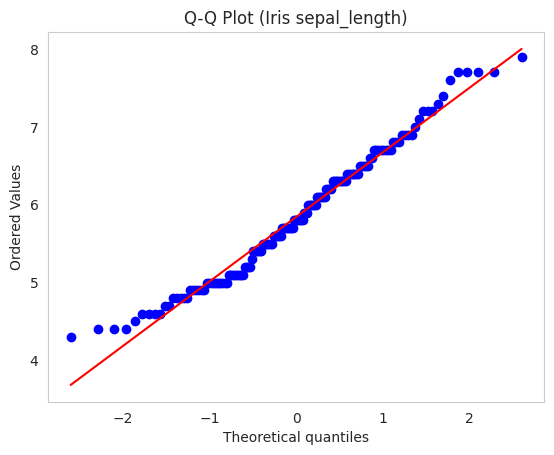

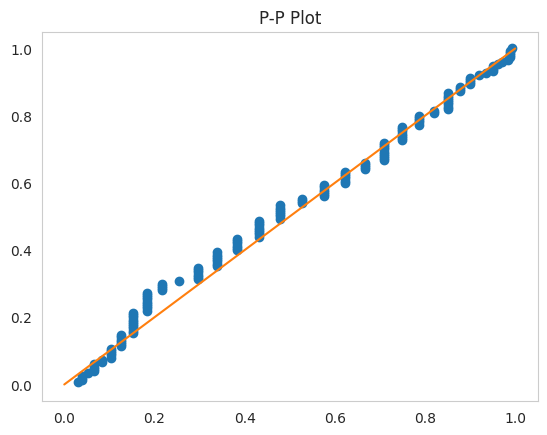

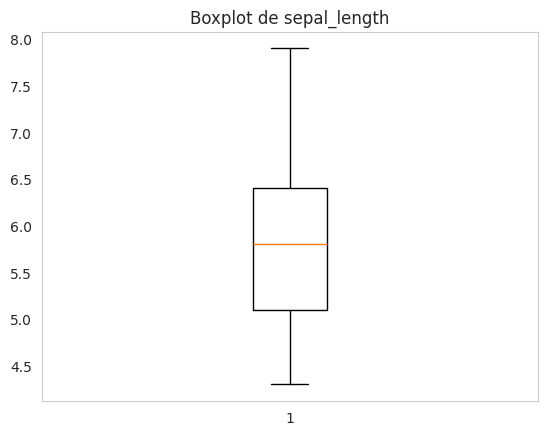

In [14]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# =========================
# 1. Cargar base de datos
# =========================
iris = sns.load_dataset("iris")

data = iris["sepal_length"].values

# =========================
# 2. PRUEBAS ESTADÍSTICAS
# =========================

# Shapiro-Wilk
sw_stat, sw_p = stats.shapiro(data)

# Kolmogorov-Smirnov (vs normal con media y std muestral)
ks_stat, ks_p = stats.kstest(
    data,
    'norm',
    args=(np.mean(data), np.std(data))
)

# Anderson-Darling
ad_result = stats.anderson(data, dist='norm')

# Jarque-Bera
jb_stat, jb_p = stats.jarque_bera(data)

print("=== Shapiro-Wilk ===")
print(sw_stat, sw_p)

print("\n=== Kolmogorov-Smirnov ===")
print(ks_stat, ks_p)

print("\n=== Jarque-Bera ===")
print(jb_stat, jb_p)

print("\n=== Anderson-Darling ===")
print(ad_result.statistic)
print(ad_result.critical_values)

# =========================
# 3. HISTOGRAMA vs NORMAL
# =========================
x = np.linspace(min(data), max(data), 200)

plt.figure()
plt.hist(data, bins=20, density=True, alpha=0.5)
plt.plot(x, stats.norm.pdf(x, np.mean(data), np.std(data)))
plt.title("Histograma vs Normal teórica")
plt.grid()
plt.show()

# =========================
# 4. Q-Q PLOT
# =========================
plt.figure()
stats.probplot(data, dist="norm", plot=plt)
plt.title("Q-Q Plot (Iris sepal_length)")
plt.grid()
plt.show()

# =========================
# 5. P-P PLOT
# =========================
data_sorted = np.sort(data)
n = len(data)
emp = np.arange(1, n+1)/n
theo = stats.norm.cdf(data_sorted, np.mean(data), np.std(data))

plt.figure()
plt.plot(theo, emp, "o")
plt.plot([0,1],[0,1])
plt.title("P-P Plot")
plt.grid()
plt.show()

# =========================
# 6. BOXPLOT
# =========================
plt.figure()
plt.boxplot(data)
plt.title("Boxplot de sepal_length")
plt.grid()
plt.show()

ANÁLISIS DE NORMALIDAD - IRIS
Variable: sepal_length
Nivel de significancia alpha = 0.05

=== Shapiro-Wilk ===
H0: Los datos provienen de una distribución normal
H1: Los datos NO provienen de una distribución normal

Estadístico W = 0.9760902723490532
p-value = 0.010181161454691156
Regla: si p < 0.05 rechazar H0

Decisión: RECHAZAR H0 (no normal)

=== Kolmogorov–Smirnov ===
H0: Los datos siguen una distribución normal
H1: Los datos NO siguen una distribución normal

Estadístico D = 0.08945440179507252
p-value = 0.17058360931631134
Regla: si p < 0.05 rechazar H0

Decisión: NO se rechaza H0

=== Jarque-Bera ===
H0: Asimetría = 0 y Curtosis = 3 (normalidad)
H1: No cumple normalidad

JB = 4.4858754373509475
p-value = 0.1061462181718774
Regla: si p < 0.05 rechazar H0

Decisión: NO se rechaza H0

=== Anderson–Darling ===
H0: Los datos provienen de una distribución normal
H1: Los datos NO provienen de una distribución normal

Estadístico A² = 0.8891994860134105
Valores críticos: [0.562 0.64  

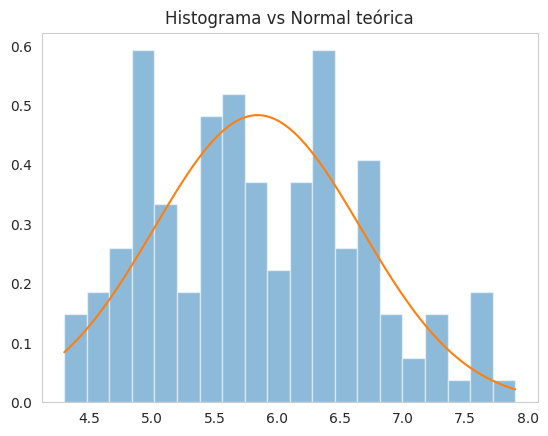

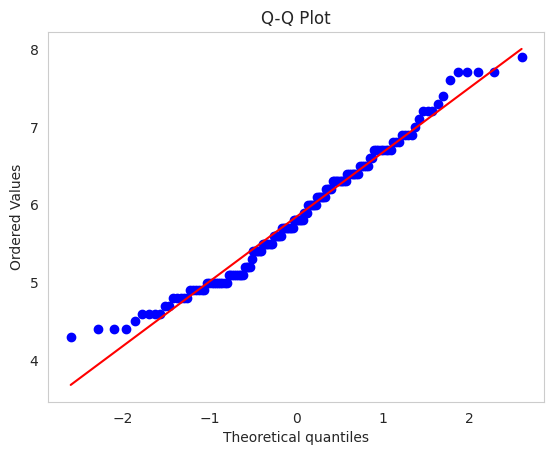

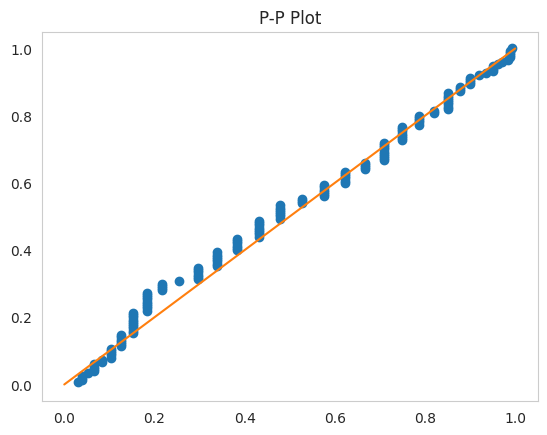

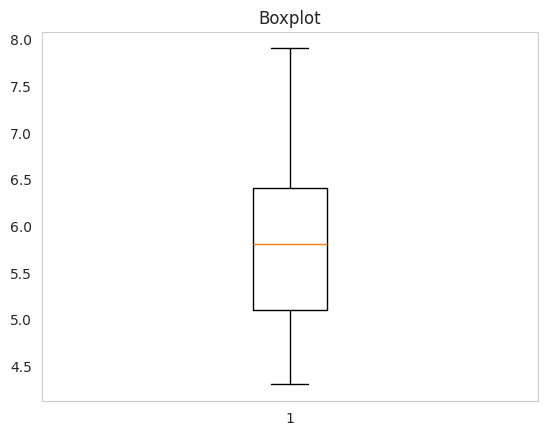

In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# =========================
# 1. Cargar base de datos
# =========================
iris = sns.load_dataset("iris")
data = iris["sepal_length"].values

alpha = 0.05

print("====================================")
print("ANÁLISIS DE NORMALIDAD - IRIS")
print("Variable: sepal_length")
print("Nivel de significancia alpha =", alpha)
print("====================================\n")

# =========================
# 2. SHAPIRO-WILK
# =========================
sw_stat, sw_p = stats.shapiro(data)

print("=== Shapiro-Wilk ===")
print("H0: Los datos provienen de una distribución normal")
print("H1: Los datos NO provienen de una distribución normal\n")

print("Estadístico W =", sw_stat)
print("p-value =", sw_p)
print("Regla: si p <", alpha, "rechazar H0\n")

if sw_p < alpha:
    print("Decisión: RECHAZAR H0 (no normal)\n")
else:
    print("Decisión: NO se rechaza H0 (compatible con normalidad)\n")

# =========================
# 3. KOLMOGOROV-SMIRNOV
# =========================
ks_stat, ks_p = stats.kstest(
    data,
    'norm',
    args=(np.mean(data), np.std(data))
)

print("=== Kolmogorov–Smirnov ===")
print("H0: Los datos siguen una distribución normal")
print("H1: Los datos NO siguen una distribución normal\n")

print("Estadístico D =", ks_stat)
print("p-value =", ks_p)
print("Regla: si p <", alpha, "rechazar H0\n")

if ks_p < alpha:
    print("Decisión: RECHAZAR H0\n")
else:
    print("Decisión: NO se rechaza H0\n")

# =========================
# 4. JARQUE-BERA
# =========================
jb_stat, jb_p = stats.jarque_bera(data)

print("=== Jarque-Bera ===")
print("H0: Asimetría = 0 y Curtosis = 3 (normalidad)")
print("H1: No cumple normalidad\n")

print("JB =", jb_stat)
print("p-value =", jb_p)
print("Regla: si p <", alpha, "rechazar H0\n")

if jb_p < alpha:
    print("Decisión: RECHAZAR H0\n")
else:
    print("Decisión: NO se rechaza H0\n")

# =========================
# 5. ANDERSON-DARLING
# =========================
ad = stats.anderson(data, dist='norm')

print("=== Anderson–Darling ===")
print("H0: Los datos provienen de una distribución normal")
print("H1: Los datos NO provienen de una distribución normal\n")

print("Estadístico A² =", ad.statistic)
print("Valores críticos:", ad.critical_values)
print("Niveles de significancia:", ad.significance_level)
print("Regla: A² > valor crítico → rechazar H0\n")

for i in range(len(ad.critical_values)):
    sl = ad.significance_level[i]
    cv = ad.critical_values[i]
    decision = "RECHAZAR H0" if ad.statistic > cv else "NO se rechaza H0"
    print(f"Nivel {sl}%: crítico={cv:.3f} -> {decision}")

# =========================
# 6. GRÁFICOS
# =========================

x = np.linspace(min(data), max(data), 200)

# Histograma
plt.figure()
plt.hist(data, bins=20, density=True, alpha=0.5)
plt.plot(x, stats.norm.pdf(x, np.mean(data), np.std(data)))
plt.title("Histograma vs Normal teórica")
plt.grid()
plt.show()

# Q-Q plot
plt.figure()
stats.probplot(data, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.grid()
plt.show()

# P-P plot
data_sorted = np.sort(data)
n = len(data)
emp = np.arange(1, n+1)/n
theo = stats.norm.cdf(data_sorted, np.mean(data), np.std(data))

plt.figure()
plt.plot(theo, emp, "o")
plt.plot([0,1],[0,1])
plt.title("P-P Plot")
plt.grid()
plt.show()

# Boxplot
plt.figure()
plt.boxplot(data)
plt.title("Boxplot")
plt.grid()
plt.show()

## Consideraciones importantes

1. Las pruebas analíticas solo indican si **rechazar o no** la hipótesis nula.
2. Para muestras muy grandes, pruebas como Shapiro-Wilk pueden rechazar H0 incluso con desviaciones mínimas de la normalidad.
3. Siempre complementar pruebas analíticas con métodos gráficos.
4. La elección de la prueba depende del tipo de datos (continuos, discretos) y del tamaño de la muestra.
5. Para pruebas de Chi-cuadrado, se recomienda que las frecuencias esperadas sean al menos 5 en cada categoría.

## Referencias

- Rincón, L. (2019). Estadística inferencial: Extracto de pruebas de hipótesis
- Casella, G., & Berger, R. L. (2002). Statistical Inference
- Lehmann, E. L., & Romano, J. P. (2005). Testing Statistical Hypotheses